---
 Title: Week 3 R^2 - values and Histograms 
 Author: Tres Reeves  
 Date: 28 June 2026  
 Description: Using US population data for R^2-values and building a histogram for our customer spending data

---
---
 Title: R-squared     
 Author: W3 Schools       
 Date: Not Dated          
 Description: Understanding R-squared in Python        
 URL: https://www.w3schools.com/datascience/ds_linear_regression_rsquared.asp    

---
---
 Title: Solving Linear Regression in Python   
 Author: GeeksforGeeks 
 Date: 12 July 2025          
 Description: Examples on how to build proper histograms in Python using Matplotlib.       
 URL: https://www.geeksforgeeks.org/data-visualization/plotting-histogram-in-python-using-matplotlib/    

---

In [41]:
# Importing all libraries needed for the project 
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 

# US Population Growth

**(a) Import the data and create two new columns. Create one column that is the number of years
since 1790. Create another column that is the population in millions.**

In [42]:
# Load the us_pop_data.csv 
df_pop = pd.read_csv('us_pop_data.csv')

# Creating years since 1790 column 
df_pop['elapsed_years_1790'] = df_pop['year'] - 1790

# Creating population in millions column 
df_pop['pop_in_million'] = df_pop['population'] / 1_000_000

print(df_pop.head())

   year  population  elapsed_years_1790  pop_in_million
0  1790     3929214                   0        3.929214
1  1800     5308483                  10        5.308483
2  1810     7239881                  20        7.239881
3  1820     9638453                  30        9.638453
4  1830    12866020                  40       12.866020


**(b) Plot the US population (in millions) versus the years since 1790.**

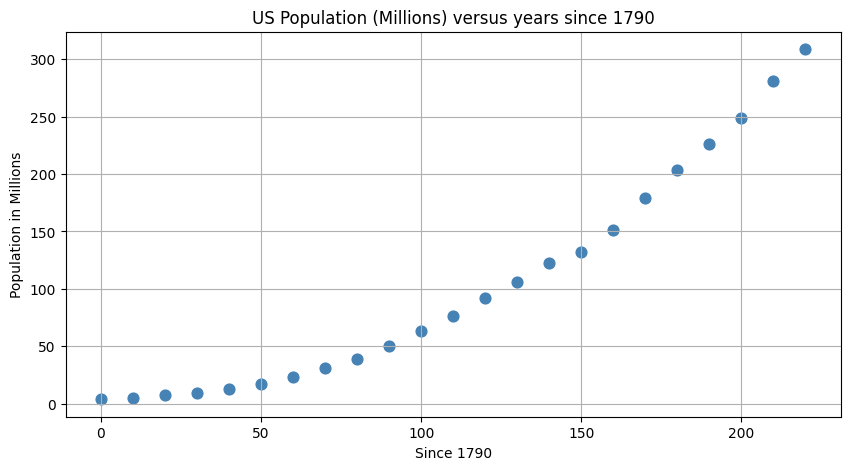

In [43]:
# figure sizing
plt.figure(figsize=(10, 5))

# Scatter plot - each dot represents one yearly census
plt.scatter(df_pop['elapsed_years_1790'], df_pop['pop_in_million'], color='steelblue', s=60)

# Labels and title 
plt.title('US Population (Millions) versus years since 1790')
plt.xlabel('Since 1790')
plt.ylabel('Population in Millions')

# Grids make data easier to read values 
plt.grid(True)
plt.show()

**(c) Create a linear regression model to predict the US population (in millions) t years from 1790.
Find and report the R2-value of this model.**

In [44]:
# Reshape X - since sklearn needs to use a 2D array
x = df_pop['elapsed_years_1790'].values.reshape(-1, 1)
y = df_pop['pop_in_million']

# Create and train the model 
linear_model = LinearRegression()
linear_model.fit(x, y)

# Grab the prediction and calculate R-Squared
y_pred = linear_model.predict(x)
# y = actual &  y_pred = Predicted 
r2_linear = r2_score(y, y_pred)

print(f'R-squared score: {r2_linear:.4f}')

R-squared score: 0.9192


**(d) Create another new column in your data by squaring the number of years since 1790.**

In [45]:
# Squaring the elapsed years column 
df_pop['years_squared'] = df_pop['elapsed_years_1790'] ** 2

print(df_pop.head())

   year  population  elapsed_years_1790  pop_in_million  years_squared
0  1790     3929214                   0        3.929214              0
1  1800     5308483                  10        5.308483            100
2  1810     7239881                  20        7.239881            400
3  1820     9638453                  30        9.638453            900
4  1830    12866020                  40       12.866020           1600


**(e) Run another linear regression, where your input feature is the square of the number of years since
1790. Find and report the R2-value of this model.**

In [46]:
# Reshape X - since sklearn needs to use a 2D array
x = df_pop['years_squared'].values.reshape(-1, 1)
y = df_pop['pop_in_million']

# Create and train the model 
quad_model = LinearRegression()
quad_model.fit(x, y)

# Grab the prediction and calculate R-Squared
y_pred = quad_model.predict(x)
# y = actual &  y_pred = Predicted 
r2_quad = r2_score(y, y_pred)

print(f'R-squared score: {r2_quad:.4f}')

R-squared score: 0.9985


**(f) Plot the models you built on top of the data. Which one fits the data better? Is this apparent in
your R2-values. Explain.**

**Answer:**    
The quadratic model fits this dataset better. In the visual, our green quadratic curve closely follows all the data points, while the red linear line goes negative from the start and consistently misses the data's curve. We also have confirmation from the R-squared values. The linear model explains 91.92% of the variation in population growth while the quadratic model explains 99.85%.The linear model has a hard time capturing the speed of US population growth, which a straight line cannot do. The quadratic model can curve upwards, though, and it also matches the speed more closely. 

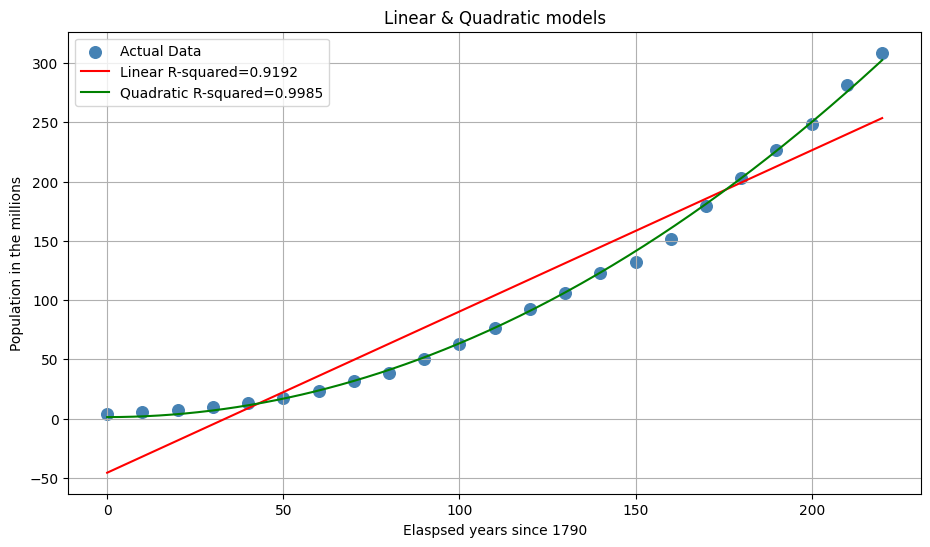

In [47]:
# x values for drawing the curves
x_range = np.linspace(0, 220, 300)

# Predictions for each model using x_range
y_linear = linear_model.predict(x_range.reshape(-1, 1))
y_quad = quad_model.predict((x_range ** 2).reshape(-1, 1))

plt.figure(figsize=(11, 6))

# Actual data points 
plt.scatter(df_pop['elapsed_years_1790'], df_pop['pop_in_million'], 
            color='steelblue', s=70, label='Actual Data')

# Linear curve
plt.plot(x_range, y_linear, color='red', label=f'Linear R-squared={r2_linear:.4f}')

# Quadratic  curve 
plt.plot(x_range, y_quad, color='green', label=f'Quadratic R-squared={r2_quad:.4f}')

# Labels and title 
plt.title('Linear & Quadratic models')
plt.xlabel("Elaspsed years since 1790")
plt.ylabel("Population in the millions")
plt.legend()


# Grids make data easier to read values 
plt.grid(True)
plt.show()

# Customer Spending Data

**(a) Make a histogram of the customer spending amounts.**

**(b) Make a new data set that is a log transformation of the customer spending amounts.**

**(c) Make a histogram of the log transformed dataset.**

**(d) Compare the two histograms. Discuss why it might be useful to apply a log transformation to
this data for modeling purposes.**